# 🗄️ Building MMAP scalar array memory optimization with restaurant data

This notebook demonstrates how to optimize memory usage in Milvus using MMAP (Memory-Mapped Files) on scalar array fields. We compare memory consumption with MMAP enabled vs disabled using large-scale restaurant data with category arrays.

### What you will learn
- Setting up Milvus collections with array fields and MMAP configuration
- Generating large-scale test data with random restaurant categories
- Measuring memory usage with Prometheus metrics after load stabilization
- Understanding the difference between RSS and heap memory in MMAP context
- Comparing MMAP on vs off for scalar array fields with visualization

### Requirements
- `pymilvus[model]`
- `pandas`
- `numpy`
- `httpx` (for Prometheus metrics)
- `matplotlib` (for visualization)
- Local Milvus instance with Prometheus endpoint

Run order: Execute cells top-to-bottom. Adjust N_ROWS and BATCH based on your hardware. Ensure Prometheus is accessible for metrics collection.

**Important Note**: MMAP benefits primarily show in **heap memory reduction**, not necessarily total RSS. We wait 10s after load for GC stabilization before capturing metrics.

Reference: For a step-by-step blog post, see https://wiphoo.dev (search for "MMAP Milvus scalar optimization").

🔎 Step 0 — Table of contents

- step 1 🔌 connect to Milvus
- step 2 🗂️ define collection schema & helper functions
- step 3 🧪 capture baseline metrics
- step 4 🏗️ create collection with MMAP off
- step 5 📥 insert test data & capture metrics (MMAP off)
- step 6 🏗️ create collection with MMAP on
- step 7 📥 insert test data & capture metrics (MMAP on)
- step 8 📊 compare & visualize results
- step 9 🧹 cleanup

Run the notebook top-to-bottom. Use the helper functions for collection creation and metric capture.

In [1]:
%pip install -q --upgrade "pymilvus[model]" pandas numpy httpx matplotlib

Note: you may need to restart the kernel to use updated packages.


🔌 Step 1 — Connect to Milvus

Establish a connection to your Milvus instance local. Update the URI or token in this cell before running other cells.

In [2]:
# Connect to Milvus
from pymilvus import MilvusClient

# Connect to local Milvus server
client = MilvusClient(uri="http://localhost:19530")

In [3]:
COLLECTION_NAME = "retaurants_mmap"

# Data size (increase gradually)
N_ROWS = 100_000  # adjust to your hardware; start smaller if needed
BATCH = 10_000

# Vector stub (minimal) — not used in queries
VEC_DIM = 4

# AVG_NUM_CATEGORIES = 163  # average number of categories per restaurant
AVG_NUM_CATEGORIES = 2048 

In [4]:
# Prometheus configuration
PROM_ENDPOINTS = [
    "http://localhost:9091/metrics",  # Update with your Prometheus endpoint
]

# Metrics to capture (memory and GC related)
PROM_METRIC_SELECTORS = [
    "process_resident_memory_bytes",     # Total RSS
    "go_memstats_alloc_bytes",           # Cumulative bytes allocated
    "go_memstats_heap_alloc_bytes",      # Current heap allocation
    "go_memstats_heap_inuse_bytes",      # Heap in-use
    "go_memstats_heap_idle_bytes",       # Heap idle
    "go_memstats_alloc_bytes",           # Bytes allocated
    "go_memstats_gc_sys_bytes",          # GC system bytes
    "go_memstats_stack_inuse_bytes",     # Stack in-use
    "go_goroutines",                     # Number of goroutines
    "go_memstats_heap_objects",          # Heap objects count
    "go_memstats_mspan_inuse_bytes",     # Mspan in-use
    "go_memstats_mcache_inuse_bytes",    # Mcache in-use
]

🗂️ Step 2 — Define collection schema & helper functions

Set up collection parameters, data size constants, and helper functions for creating collections, building indexes, and inserting test data.

Configuration notes:
- Adjust `N_ROWS` and `BATCH` based on your hardware capacity.
- `AVG_NUM_CATEGORIES` controls the average array size per record (using Poisson distribution).
- Array field `max_capacity` should accommodate the maximum expected array size.

In [5]:
import numpy as np
import uuid
from pymilvus import DataType


def create_collection(collection_name, mmap_on_categories=True):
    """
    Create a Milvus collection with array field and MMAP configuration.
    
    Args:
        collection_name (str): Name of the collection to create
        mmap_on_categories (bool): Enable MMAP on the categories array field
        
    Returns:
        Collection object after creation
    """
    # Drop existing collection if present
    if collection_name in client.list_collections():
        client.drop_collection(collection_name)
        print(f"Dropped existing collection: {collection_name}")

    # Create schema with disabled dynamic fields for strict control
    schema = MilvusClient.create_schema(
        auto_id=False,
        enable_dynamic_field=False,
    )

    # Add primary key and metadata fields
    schema.add_field(
        field_name="id",
        datatype=DataType.VARCHAR,
        is_primary=True,
        auto_id=False,
        max_length=128
    )
    schema.add_field(
        field_name="title",
        datatype=DataType.VARCHAR,
        max_length=512
    )
    schema.add_field(
        field_name="latitude",
        datatype=DataType.FLOAT
    )
    schema.add_field(
        field_name="longitude",
        datatype=DataType.FLOAT
    )

    # Add array field with MMAP configuration (key field for this demo)
    schema.add_field(
        field_name="categories",
        datatype=DataType.ARRAY,
        element_type=DataType.INT32,
        max_capacity=4096,
        mmap=mmap_on_categories,  # MMAP optimization toggle
    )

    # Add minimal vector field (not used in this demo, but required for collection)
    schema.add_field(
        field_name="stub_vector",
        datatype=DataType.FLOAT_VECTOR,
        dim=VEC_DIM
    )

    # Create collection with schema
    collection = client.create_collection(
        collection_name=collection_name,
        schema=schema
    )
    
    print(f"✓ Collection '{collection_name}' created with MMAP on categories: {mmap_on_categories}")
    return collection


def build_index(collection_name):
    """
    Build indexes for vector and array fields.
    
    Args:
        collection_name (str): Name of the collection to index
        
    Returns:
        Index creation result
    """
    index_params = client.prepare_index_params()

    # Index for stub vector field (minimal configuration)
    index_params.add_index(
        field_name="stub_vector",
        index_type="IVF_FLAT",
        metric_type="IP",
    )
    
    # Index for categories array field (inverted index for filtering)
    index_params.add_index(
        field_name="categories",
        index_type="INVERTED",
    )

    result = client.create_index(collection_name, index_params)
    print(f"✓ Indexes created for collection: {collection_name}")
    return result


def insert_data(collection_name):
    """
    Generate and insert random test data in batches.
    
    Args:
        collection_name (str): Name of the collection to insert data into
        
    This function generates random restaurant data with:
    - UUID primary keys
    - Random coordinates
    - Poisson-distributed category arrays (avg: AVG_NUM_CATEGORIES)
    """
    total_inserted = 0
    
    print(f"Starting batch insertion: {N_ROWS:,} rows in batches of {BATCH:,}...")
    
    for start_idx in range(0, N_ROWS, BATCH):
        end_idx = min(start_idx + BATCH, N_ROWS)
        batch_size = end_idx - start_idx
        
        # Generate random entities for this batch
        entities = []
        for idx in range(batch_size):
            # Generate random category count using Poisson distribution
            num_categories = np.random.poisson(AVG_NUM_CATEGORIES)
            # Ensure we don't exceed available categories or max_capacity
            num_categories = min(num_categories, 8192, 4096)
            
            entity = {
                "id": str(uuid.uuid4()),
                "title": f"Restaurant {start_idx + idx}",
                "latitude": float(np.random.uniform(-90, 90)),
                "longitude": float(np.random.uniform(-180, 180)),
                "categories": np.random.choice(
                    8192,
                    size=num_categories,
                    replace=False
                ).tolist(),
                "stub_vector": [0.1, 0.2, 0.3, 0.4],  # Placeholder vector
            }
            entities.append(entity)
        
        # Insert batch
        client.insert(collection_name, entities)
        total_inserted += len(entities)
        
        # Progress update
        batch_num = start_idx // BATCH + 1
        print(f"  Batch {batch_num}: {len(entities):,} records (total: {total_inserted:,})")

    # Flush and load collection
    client.flush(collection_name)
    client.load_collection(collection_name)
    
    print(f"✓ Insertion complete: {total_inserted:,} records inserted and loaded")

---

📊 Step 3 — Capture baseline metrics

Capture initial Prometheus metrics before any data loading to establish a baseline for comparison.

In [6]:
import re
import time
import httpx
import pandas as pd

# Compile regex selectors for efficient matching
selectors = [re.compile(s) for s in PROM_METRIC_SELECTORS]


def parse_prometheus_text(text, endpoint_tag):
    """
    Parse Prometheus text format metrics into structured data.
    
    Args:
        text (str): Raw Prometheus metrics text
        endpoint_tag (str): Tag to identify the endpoint source
        
    Returns:
        pd.DataFrame: Parsed metrics with columns: metric, value, endpoint, labels, ts
    """
    rows = []
    
    for line in text.splitlines():
        # Skip comments and empty lines
        if not line or line.startswith('#'):
            continue
            
        # Parse metric line: metric_name{labels} value
        match = re.match(
            r"^([a-zA-Z_:][a-zA-Z0-9_:]*)(\{[^}]*\})?\s+([+-]?(?:\d*\.\d+|\d+)(?:[eE][+-]?\d+)?)$",
            line
        )
        if not match:
            continue
            
        name, label_blob, value = match.group(1), match.group(2), float(match.group(3))
        
        # Filter by selectors
        if selectors and not any(sel.search(name) for sel in selectors):
            continue
        
        # Parse labels
        labels = {}
        if label_blob:
            for kv in label_blob.strip('{}').split(','):
                if not kv:
                    continue
                k, _, v = kv.partition('=')
                labels[k.strip()] = v.strip('"')
        
        # Build row with flattened label columns
        row = {
            "metric": name,
            "value": value,
            "endpoint": endpoint_tag,
            **{f"lbl_{k}": v for k, v in labels.items()}
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df["ts"] = time.time()
    
    return df


def scrape_prometheus(endpoints):
    """
    Scrape metrics from multiple Prometheus endpoints using httpx.
    
    Args:
        endpoints (list): List of Prometheus endpoint URLs
        
    Returns:
        pd.DataFrame: Combined metrics from all endpoints
    """
    frames = []
    
    # Use httpx client for HTTP requests
    with httpx.Client(timeout=3.0) as client:
        for url in endpoints:
            try:
                response = client.get(url)
                response.raise_for_status()
                frames.append(parse_prometheus_text(response.text, url))
            except Exception as e:
                # Log error as a metric row
                error_df = pd.DataFrame([{
                    "metric": "__error__",
                    "value": None,
                    "endpoint": url,
                    "lbl_error": str(e)
                }])
                frames.append(error_df)
    
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def capture_prom_series(tag):
    """
    Capture a single snapshot of Prometheus metrics.
    
    Args:
        tag (str): Phase tag for this capture (e.g., "baseline", "post_load")
        
    Returns:
        pd.DataFrame: Metrics with phase label
    """
    df = scrape_prometheus(PROM_ENDPOINTS)
    if df.empty:
        return df
    
    df["phase"] = tag
    return df


def capture_prom_average(duration_seconds=30, interval_seconds=1, tag="average"):
    """
    Capture Prometheus metrics over a time window and compute averages.
    
    This function collects metrics at regular intervals over a specified duration,
    then computes mean, standard deviation, and sample count for each metric.
    This smooths out noise and provides more stable measurements.
    
    Args:
        duration_seconds (int): Total time to collect metrics (default 30s)
        interval_seconds (int): Time between samples (default 1s)
        tag (str): Phase tag for the captured data
    
    Returns:
        pd.DataFrame: Averaged metrics with columns:
            - metric: Metric name
            - endpoint: Endpoint URL
            - lbl_*: Label columns
            - value: Mean value over the window
            - std_dev: Standard deviation
            - samples: Number of samples
            - phase, run: Metadata tags
            - window_start, window_duration, total_samples: Timing info
    """
    samples = []
    start_time = time.time()
    end_time = start_time + duration_seconds
    
    print(f"Collecting metrics for {duration_seconds}s at {interval_seconds}s intervals...")
    
    # Collect samples at regular intervals
    while time.time() < end_time:
        sample_start = time.time()
        df = scrape_prometheus(PROM_ENDPOINTS)
        
        if not df.empty:
            samples.append(df)
        
        # Wait for next interval, accounting for collection time
        elapsed = time.time() - sample_start
        sleep_time = max(0, interval_seconds - elapsed)
        time.sleep(sleep_time)
    
    if not samples:
        print("⚠ No samples collected")
        return pd.DataFrame()
    
    # Combine all samples
    combined_df = pd.concat(samples, ignore_index=True)
    
    # Group by metric and labels, compute statistics
    group_cols = ['metric', 'endpoint'] + [
        col for col in combined_df.columns if col.startswith('lbl_')
    ]
    avg_df = combined_df.groupby(group_cols, dropna=False)['value'].agg([
        ('value', 'mean'),
        ('std_dev', 'std'),
        ('samples', 'count')
    ]).reset_index()
    
    # Add metadata
    avg_df["phase"] = tag
    avg_df["window_start"] = start_time
    avg_df["window_duration"] = duration_seconds
    avg_df["total_samples"] = len(samples)
    
    print(f"✓ Collected {len(samples)} samples over {duration_seconds}s, averaged {len(avg_df)} metrics")
    return avg_df

In [7]:
# Configure pandas display for better readability
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:.0f}')  # Show integers without decimals

Set pandas display options for better metric readability.

In [8]:
# Capture baseline metrics (before loading any data)
print("📊 Capturing baseline metrics...")
df_baseline = capture_prom_average(
    duration_seconds=10,
    interval_seconds=2,
    tag="baseline"
)
df_baseline

📊 Capturing baseline metrics...
✓ Collected 5 samples over 10s, averaged 12 metrics
✓ Collected 5 samples over 10s, averaged 12 metrics


,metric,endpoint,value,std_dev,samples,phase,window_start,window_duration,total_samples
0,go_goroutines,http://localhost:9091/metrics,537,1,5,baseline,1759788050,10,5
1,go_memstats_alloc_bytes,http://localhost:9091/metrics,82437086,14975273,5,baseline,1759788050,10,5
2,go_memstats_alloc_bytes_total,http://localhost:9091/metrics,270842843790,14975273,5,baseline,1759788050,10,5
3,go_memstats_gc_sys_bytes,http://localhost:9091/metrics,10566752,0,5,baseline,1759788050,10,5
4,go_memstats_heap_alloc_bytes,http://localhost:9091/metrics,82437086,14975273,5,baseline,1759788050,10,5
5,go_memstats_heap_idle_bytes,http://localhost:9091/metrics,1996854067,11093996,5,baseline,1759788050,10,5
6,go_memstats_heap_inuse_bytes,http://localhost:9091/metrics,99170714,11041566,5,baseline,1759788050,10,5
7,go_memstats_heap_objects,http://localhost:9091/metrics,888156,254545,5,baseline,1759788050,10,5
8,go_memstats_mcache_inuse_bytes,http://localhost:9091/metrics,19328,0,5,baseline,1759788050,10,5
9,go_memstats_mspan_inuse_bytes,http://localhost:9091/metrics,1473184,161682,5,baseline,1759788050,10,5


Capture baseline metrics (no collection loaded).

---

🏗️ Step 4 — Create collection with MMAP off

Create a collection with MMAP disabled on the categories array field, build indexes, insert test data, and capture memory metrics after stabilization.

In [9]:
# Create collection without MMAP
create_collection(COLLECTION_NAME, mmap_on_categories=False)

# Build indexes
build_index(COLLECTION_NAME)

# Insert test data
insert_data(COLLECTION_NAME)

# Wait for garbage collection and memory stabilization
print("\n⏳ Waiting 10s for GC and memory stabilization...")
time.sleep(10)

# Capture metrics after stabilization
print("📊 Capturing metrics after load stabilization...")
df_mmap_off = capture_prom_average(
    duration_seconds=30,
    interval_seconds=2,
    tag="load_mmap_off"
)
df_mmap_off

✓ Collection 'retaurants_mmap' created with MMAP on categories: False
✓ Indexes created for collection: retaurants_mmap
Starting batch insertion: 100,000 rows in batches of 10,000...
✓ Indexes created for collection: retaurants_mmap
Starting batch insertion: 100,000 rows in batches of 10,000...
  Batch 1: 10,000 records (total: 10,000)
  Batch 1: 10,000 records (total: 10,000)
  Batch 2: 10,000 records (total: 20,000)
  Batch 2: 10,000 records (total: 20,000)
  Batch 3: 10,000 records (total: 30,000)
  Batch 3: 10,000 records (total: 30,000)
  Batch 4: 10,000 records (total: 40,000)
  Batch 4: 10,000 records (total: 40,000)
  Batch 5: 10,000 records (total: 50,000)
  Batch 5: 10,000 records (total: 50,000)
  Batch 6: 10,000 records (total: 60,000)
  Batch 6: 10,000 records (total: 60,000)
  Batch 7: 10,000 records (total: 70,000)
  Batch 7: 10,000 records (total: 70,000)
  Batch 8: 10,000 records (total: 80,000)
  Batch 8: 10,000 records (total: 80,000)
  Batch 9: 10,000 records (total

,metric,endpoint,value,std_dev,samples,phase,window_start,window_duration,total_samples
0,go_goroutines,http://localhost:9091/metrics,564,9,15,load_mmap_off,1759788125,30,15
1,go_memstats_alloc_bytes,http://localhost:9091/metrics,154706466,38170927,15,load_mmap_off,1759788125,30,15
2,go_memstats_alloc_bytes_total,http://localhost:9091/metrics,277554143197,50709622,15,load_mmap_off,1759788125,30,15
3,go_memstats_gc_sys_bytes,http://localhost:9091/metrics,10566752,0,15,load_mmap_off,1759788125,30,15
4,go_memstats_heap_alloc_bytes,http://localhost:9091/metrics,154706466,38170927,15,load_mmap_off,1759788125,30,15
5,go_memstats_heap_idle_bytes,http://localhost:9091/metrics,1922331989,32023739,15,load_mmap_off,1759788125,30,15
6,go_memstats_heap_inuse_bytes,http://localhost:9091/metrics,173644732,32049028,15,load_mmap_off,1759788125,30,15
7,go_memstats_heap_objects,http://localhost:9091/metrics,1005158,648335,15,load_mmap_off,1759788125,30,15
8,go_memstats_mcache_inuse_bytes,http://localhost:9091/metrics,19328,0,15,load_mmap_off,1759788125,30,15
9,go_memstats_mspan_inuse_bytes,http://localhost:9091/metrics,1637931,510400,15,load_mmap_off,1759788125,30,15


Display MMAP off metrics.

---

🏗️ Step 5 — Create collection with MMAP on

Create a collection with MMAP enabled on the categories array field, build indexes, insert test data, and capture memory metrics after stabilization.

Load the collection and capture memory metrics with MMAP enabled.

In [10]:
# Create collection with MMAP enabled
create_collection(COLLECTION_NAME, mmap_on_categories=True)

# Build indexes
build_index(COLLECTION_NAME)

# Insert test data
insert_data(COLLECTION_NAME)

# Wait for garbage collection and memory stabilization
print("\n⏳ Waiting 10s for GC and memory stabilization...")
time.sleep(10)

# Capture metrics after stabilization
print("📊 Capturing metrics after load stabilization...")
df_mmap_on = capture_prom_average(
    duration_seconds=30,
    interval_seconds=2,
    tag="load_mmap_on"
)
df_mmap_on

Dropped existing collection: retaurants_mmap
✓ Collection 'retaurants_mmap' created with MMAP on categories: True
✓ Indexes created for collection: retaurants_mmap
Starting batch insertion: 100,000 rows in batches of 10,000...
✓ Indexes created for collection: retaurants_mmap
Starting batch insertion: 100,000 rows in batches of 10,000...
  Batch 1: 10,000 records (total: 10,000)
  Batch 1: 10,000 records (total: 10,000)
  Batch 2: 10,000 records (total: 20,000)
  Batch 2: 10,000 records (total: 20,000)
  Batch 3: 10,000 records (total: 30,000)
  Batch 3: 10,000 records (total: 30,000)
  Batch 4: 10,000 records (total: 40,000)
  Batch 4: 10,000 records (total: 40,000)
  Batch 5: 10,000 records (total: 50,000)
  Batch 5: 10,000 records (total: 50,000)
  Batch 6: 10,000 records (total: 60,000)
  Batch 6: 10,000 records (total: 60,000)
  Batch 7: 10,000 records (total: 70,000)
  Batch 7: 10,000 records (total: 70,000)
  Batch 8: 10,000 records (total: 80,000)
  Batch 8: 10,000 records (tot

,metric,endpoint,value,std_dev,samples,phase,window_start,window_duration,total_samples
0,go_goroutines,http://localhost:9091/metrics,562,5,15,load_mmap_on,1759788220,30,15
1,go_memstats_alloc_bytes,http://localhost:9091/metrics,125806054,22979656,15,load_mmap_on,1759788220,30,15
2,go_memstats_alloc_bytes_total,http://localhost:9091/metrics,284402584000,56003746,15,load_mmap_on,1759788220,30,15
3,go_memstats_gc_sys_bytes,http://localhost:9091/metrics,10566752,0,15,load_mmap_on,1759788220,30,15
4,go_memstats_heap_alloc_bytes,http://localhost:9091/metrics,125806054,22979656,15,load_mmap_on,1759788220,30,15
5,go_memstats_heap_idle_bytes,http://localhost:9091/metrics,1948430609,16616050,15,load_mmap_on,1759788220,30,15
6,go_memstats_heap_inuse_bytes,http://localhost:9091/metrics,147635678,16593084,15,load_mmap_on,1759788220,30,15
7,go_memstats_heap_objects,http://localhost:9091/metrics,732246,447172,15,load_mmap_on,1759788220,30,15
8,go_memstats_mcache_inuse_bytes,http://localhost:9091/metrics,19328,0,15,load_mmap_on,1759788220,30,15
9,go_memstats_mspan_inuse_bytes,http://localhost:9091/metrics,1491563,280327,15,load_mmap_on,1759788220,30,15


Display MMAP on metrics.

---

📊 Step 6 — Compare & visualize results

Compare memory metrics between MMAP on and off configurations. Generate visualization charts and summary statistics to understand the memory impact.

Compare the memory metrics between MMAP on and off using bar charts and detailed statistics.

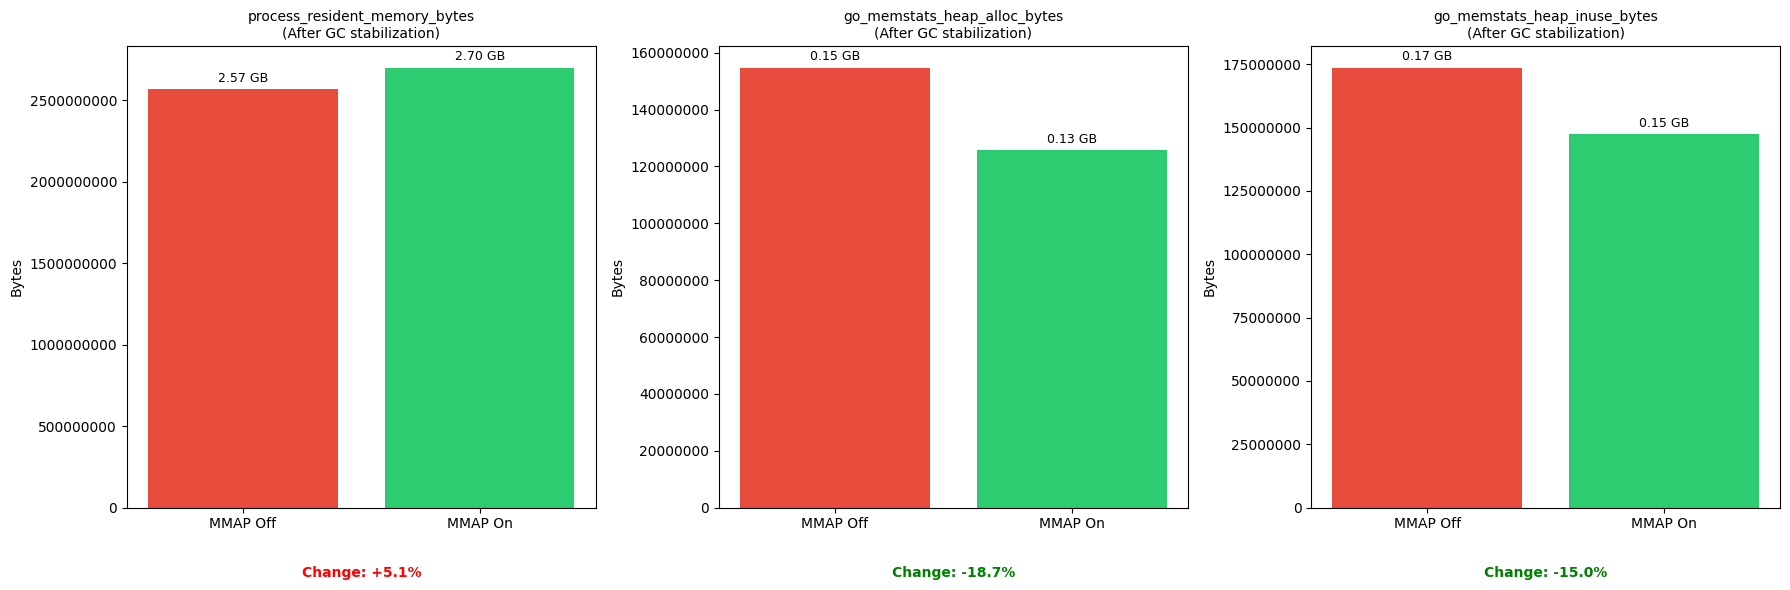


MEMORY USAGE COMPARISON (AFTER GC STABILIZATION)

📊 process_resident_memory_bytes:
   MMAP Off: 2.569 GB
   MMAP On:  2.701 GB
   Change:   +0.132 GB (+5.1%)
   ⚠️  MMAP uses MORE memory (page cache effect)

📊 go_memstats_heap_alloc_bytes:
   MMAP Off: 0.155 GB
   MMAP On:  0.126 GB
   Change:   -0.029 GB (-18.7%)
   ✅ MMAP saves 0.029 GB

📊 go_memstats_heap_inuse_bytes:
   MMAP Off: 0.174 GB
   MMAP On:  0.148 GB
   Change:   -0.026 GB (-15.0%)
   ✅ MMAP saves 0.026 GB

💡 UNDERSTANDING THE RESULTS:

1. process_resident_memory_bytes (RSS):
   - Total memory including heap + page cache
   - May be HIGHER with MMAP due to memory-mapped pages
   - This is GOOD: pages can be evicted when memory is needed

2. go_memstats_heap_alloc_bytes (Heap Allocations):
   - Go runtime heap memory
   - Should be LOWER with MMAP
   - This is the key benefit: less heap = less GC pressure

3. go_memstats_heap_inuse_bytes (Heap In-Use):
   - Active heap memory
   - Should be LOWER with MMAP
   - Confirms d

In [11]:
import matplotlib.pyplot as plt

# Define key memory metrics to compare
memory_metrics = [
    'process_resident_memory_bytes',  # Total RSS (heap + page cache)
    'go_memstats_heap_alloc_bytes',   # Current heap allocations
    'go_memstats_heap_inuse_bytes',   # Heap memory in use
]

# Extract data for each configuration
df_off_load = df_mmap_off[df_mmap_off['phase'] == 'load_mmap_off']
df_on_load = df_mmap_on[df_mmap_on['phase'] == 'load_mmap_on']


def get_metric_value(df, metric_name):
    """Helper to safely extract metric value from dataframe."""
    filtered = df[df['metric'] == metric_name]
    return filtered['value'].iloc[0] if not filtered.empty else 0


# Create comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(memory_metrics):
    # Get values for MMAP off and on
    off_val = get_metric_value(df_off_load, metric)
    on_val = get_metric_value(df_on_load, metric)
    
    if off_val > 0 and on_val > 0:
        # Create bar chart
        axes[i].bar(
            ['MMAP Off', 'MMAP On'],
            [off_val, on_val],
            color=['#e74c3c', '#2ecc71']
        )
        
        # Set labels and title
        axes[i].set_title(f'{metric}\n(After GC stabilization)', fontsize=10)
        axes[i].set_ylabel('Bytes')
        axes[i].ticklabel_format(style='plain', axis='y')
        
        # Add value labels on bars (in GB)
        for j, val in enumerate([off_val, on_val]):
            axes[i].text(
                j, val * 1.01,
                f'{val/1e9:.2f} GB',
                ha='center', va='bottom', fontsize=9
            )
        
        # Show percentage change
        diff_pct = ((on_val - off_val) / off_val) * 100
        color = 'green' if diff_pct < 0 else 'red'
        axes[i].text(
            0.5, -0.15,
            f'Change: {diff_pct:+.1f}%',
            ha='center', transform=axes[i].transAxes,
            color=color, fontweight='bold'
        )
    else:
        # Handle missing data
        axes[i].text(
            0.5, 0.5, 'No data available',
            ha='center', va='center', transform=axes[i].transAxes
        )
        axes[i].set_title(f'{metric}\n(No data)')

plt.tight_layout()
plt.show()


# Print detailed summary
print("\n" + "="*80)
print("MEMORY USAGE COMPARISON (AFTER GC STABILIZATION)")
print("="*80)

for metric in memory_metrics:
    off_row = df_off_load[df_off_load['metric'] == metric]
    on_row = df_on_load[df_on_load['metric'] == metric]
    
    if not off_row.empty and not on_row.empty:
        off_val = off_row['value'].iloc[0]
        on_val = on_row['value'].iloc[0]
        diff = on_val - off_val
        diff_pct = (diff / off_val) * 100
        
        # Print comparison
        print(f"\n📊 {metric}:")
        print(f"   MMAP Off: {off_val/1e9:.3f} GB")
        print(f"   MMAP On:  {on_val/1e9:.3f} GB")
        print(f"   Change:   {diff/1e9:+.3f} GB ({diff_pct:+.1f}%)")
        
        # Interpretation
        if diff > 0:
            print(f"   ⚠️  MMAP uses MORE memory (page cache effect)")
        else:
            print(f"   ✅ MMAP saves {abs(diff)/1e9:.3f} GB")


# Print key insights
print("\n" + "="*80)
print("💡 UNDERSTANDING THE RESULTS:")
print("="*80)
print("""
1. process_resident_memory_bytes (RSS):
   - Total memory including heap + page cache
   - May be HIGHER with MMAP due to memory-mapped pages
   - This is GOOD: pages can be evicted when memory is needed

2. go_memstats_heap_alloc_bytes (Heap Allocations):
   - Go runtime heap memory
   - Should be LOWER with MMAP
   - This is the key benefit: less heap = less GC pressure

3. go_memstats_heap_inuse_bytes (Heap In-Use):
   - Active heap memory
   - Should be LOWER with MMAP
   - Confirms data moved from heap to memory-mapped files
""")
print("="*80)

Display comparison results with detailed analysis.

### Why You See Higher RSS with MMAP

**TL;DR:** Focus on heap metrics, not RSS. Here's why:

| Metric | MMAP Off | MMAP On | Why? |
|--------|----------|---------|------|
| **RSS** | Lower | Higher | Page cache holds mmap'd files (but evictable) |
| **Heap** | Higher | Lower | Data in Go heap vs disk-backed memory |
| **GC Pressure** | Higher | Lower | Less heap = fewer GC cycles |

💡 **The real benefit of MMAP is reduced heap pressure and better memory efficiency under load, not necessarily lower RSS!**

---

🧹 Step 7 — Cleanup

Drop the collection to free resources and capture post-cleanup metrics.

Drop the collection to clean up resources.

In [12]:
# Drop the collection
client.drop_collection(COLLECTION_NAME)
print(f"✓ Collection '{COLLECTION_NAME}' dropped")

# Capture post-cleanup metrics
print("\n📊 Capturing post-cleanup metrics...")
df_after_drop = capture_prom_average(
    duration_seconds=10,
    interval_seconds=2,
    tag="after_drop"
)
df_after_drop

✓ Collection 'retaurants_mmap' dropped

📊 Capturing post-cleanup metrics...
✓ Collected 5 samples over 10s, averaged 12 metrics
✓ Collected 5 samples over 10s, averaged 12 metrics


,metric,endpoint,value,std_dev,samples,phase,window_start,window_duration,total_samples
0,go_goroutines,http://localhost:9091/metrics,542,5,5,after_drop,1759788251,10,5
1,go_memstats_alloc_bytes,http://localhost:9091/metrics,106644816,75064174,5,after_drop,1759788251,10,5
2,go_memstats_alloc_bytes_total,http://localhost:9091/metrics,284517665936,15386099,5,after_drop,1759788251,10,5
3,go_memstats_gc_sys_bytes,http://localhost:9091/metrics,10566752,0,5,after_drop,1759788251,10,5
4,go_memstats_heap_alloc_bytes,http://localhost:9091/metrics,106644816,75064174,5,after_drop,1759788251,10,5
5,go_memstats_heap_idle_bytes,http://localhost:9091/metrics,1963399578,62860305,5,after_drop,1759788251,10,5
6,go_memstats_heap_inuse_bytes,http://localhost:9091/metrics,132749722,62836020,5,after_drop,1759788251,10,5
7,go_memstats_heap_objects,http://localhost:9091/metrics,984308,911328,5,after_drop,1759788251,10,5
8,go_memstats_mcache_inuse_bytes,http://localhost:9091/metrics,19328,0,5,after_drop,1759788251,10,5
9,go_memstats_mspan_inuse_bytes,http://localhost:9091/metrics,1818464,647437,5,after_drop,1759788251,10,5


Display post-cleanup metrics.

---

📚 Step 8 — References

Additional resources and documentation for MMAP in Milvus and related technologies.

- [Milvus Documentation: MMAP](https://milvus.io/docs/mmap.md)
- [Milvus Python SDK](https://milvus.io/docs/manage-collections.md)
- [Milvus Prometheus Metrics](https://milvus.io/docs/monitor_overview.md)
- [Memory-Mapped Files](https://en.wikipedia.org/wiki/Memory-mapped_file)